# SLIIT IT3051 - Data Mining & Predictive Analytics
## EV Battery Prognostics & Health Management (PHM)
### Stage 6 & Stage 7 — Person A: Task 1 Linear & Regularized Regression

**Target:** `predicted_remaining_life_cycles`  
**Problem type:** Regression  
**Person A modelling scope:** Dummy Regressor, Linear Regression, Ridge Regression, and Lasso Regression.

This notebook is intentionally limited to Person A's assigned modelling work. The Phase 1 feature engineering and preprocessing decisions are reused only so this notebook can reproduce the same Task 1 input data.

**Out of scope in this notebook:** tree/ensemble regressors, residual-error analysis, Task 2 classification, imbalance handling, threshold tuning, and the group master leaderboard.


## 1. Objectives

The goals of Person A's work are to:

1. Establish a naive regression benchmark using `DummyRegressor`.
2. Train an ordinary Multiple Linear Regression baseline.
3. Train Ridge and Lasso regularized regression models.
4. Evaluate all models with **R², RMSE, and MAE**.
5. Tune the regularization strength `alpha` for Ridge and Lasso using a **separate validation split created only from the training data**.
6. Compare baseline and tuned linear-family models systematically.
7. Identify the strongest **Person A linear-family candidate** for later comparison with the models developed by the other group members.

The final group model is **not** selected in this notebook.


## 2. Environment Setup


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42

print("Environment initialized successfully.")


Environment initialized successfully.


### Analysis & Viva Preparation Notes

**Observed result:** The environment initializes successfully.

**What this cell does:** It imports the libraries required for data handling, preprocessing, model training, evaluation, and plotting. `RANDOM_STATE = 42` is fixed so that the data split is reproducible.

**Viva points to remember:**
- Pandas is used for tabular data handling.
- NumPy is used for numerical operations.
- Scikit-learn provides the preprocessing pipelines, regression algorithms, splitting methods, and evaluation metrics.
- Fixing the random state makes the experiment reproducible.


## 3. Load the Dataset

The path logic below allows the notebook to run either from the repository root or from a `notebooks/` folder.


In [2]:
DATASET_NAMES = [
    "ev battery_failure  Dataset.csv",
    "ev battery_failure prediction Dataset.csv"
]

candidate_paths = []
for dataset_name in DATASET_NAMES:
    candidate_paths.extend([
        dataset_name,
        os.path.join("..", dataset_name),
        os.path.join("..", "..", dataset_name)
    ])

DATASET_PATH = next(
    (path for path in candidate_paths if os.path.exists(path)),
    None
)

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Could not find the EV battery dataset. "
        "Place the CSV in the repository root or update DATASET_NAMES."
    )

df = pd.read_csv(DATASET_PATH)

print(f"Dataset path: {DATASET_PATH}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Dataset path: ev battery_failure  Dataset.csv
Dataset shape: 20,000 rows × 70 columns


## 4. Reuse the Phase 1 Features



In [3]:
# Reproduce the same seven domain features already established in Phase 1.
df["temperature_spread"] = (
    df["cell_temperature_max"] - df["cell_temperature_avg"]
)

df["efficiency_gap"] = (
    df["charge_efficiency"] - df["discharge_efficiency"]
).abs()

df["health_loss_interaction"] = (
    df["battery_health_percent"] * df["capacity_loss_percent"]
) / 100.0

df["resistance_per_1000_cycles"] = (
    df["internal_resistance"] / (df["cycle_count"] + 1.0)
) * 1000.0

df["c_rate_proxy"] = (
    df["average_charge_power_kw"] /
    (df["battery_capacity_kwh"] + 1e-5)
)

df["cell_voltage_spread"] = (
    df["cell_voltage_std"] /
    (df["cell_voltage_avg"] + 1e-5)
)

df["stress_index"] = (
    df["aggressive_acceleration_score"] *
    df["hard_braking_score"]
)

print("Phase 1 engineered features reproduced.")


Phase 1 engineered features reproduced.


## 5. Prepare Task 1 — Remaining Life Cycles Regression

The regression target is `predicted_remaining_life_cycles`.

- Rows with a missing regression target are excluded because target labels should not be imputed.
- `vehicle_id` and `battery_serial` are identifiers and are not used as predictors.
- `battery_failure` is the Task 2 target and is excluded from Task 1 predictors.


In [4]:
TARGET_RUL = "predicted_remaining_life_cycles"
TARGET_FAIL = "battery_failure"

ID_COLUMNS = ["vehicle_id", "battery_serial"]

excluded_columns = ID_COLUMNS + [TARGET_RUL, TARGET_FAIL]

predictor_features = [
    column for column in df.columns
    if column not in excluded_columns
]

# Use only rows that have an observed regression target.
df_task1 = df[df[TARGET_RUL].notna()].copy()

X = df_task1[predictor_features]
y = df_task1[TARGET_RUL]

numerical_features = (
    X.select_dtypes(include=[np.number]).columns.tolist()
)

categorical_features = (
    X.select_dtypes(include=["object", "string", "category"])
     .columns.tolist()
)

print(f"Valid Task 1 rows:        {len(df_task1):,}")
print(f"Predictor columns:        {len(predictor_features):,}")
print(f"Numerical predictors:     {len(numerical_features):,}")
print(f"Categorical predictors:   {len(categorical_features):,}")
print(f"Missing RUL labels removed: {df[TARGET_RUL].isna().sum():,}")


Valid Task 1 rows:        19,102
Predictor columns:        73
Numerical predictors:     65
Categorical predictors:   8
Missing RUL labels removed: 898


### Analysis & Viva Preparation Notes

**Observed result:**
- Valid Task 1 rows: **19,102**
- Missing RUL labels removed: **898**
- Predictor columns: **73**
- Numerical predictors: **65**
- Categorical predictors: **8**

**Why the 898 rows are removed:** `predicted_remaining_life_cycles` is the regression target. Missing target values are not imputed because doing so would create artificial ground-truth labels.

**Why IDs and `battery_failure` are excluded:** `vehicle_id` and `battery_serial` are identifiers rather than meaningful predictive measurements, while `battery_failure` belongs to Task 2 and is excluded from the Task 1 predictor set.


## 6. Outer Train/Test Split

The same 80/20 split design is used.

The **test set is kept separate from hyperparameter selection**. Ridge and Lasso alpha values will be selected using a validation subset created only from the training partition.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples:  {X_test.shape[0]:,}")


Training samples: 15,281
Testing samples:  3,821


### Analysis & Viva Preparation Notes

**Observed result:**
- Training samples: **15,281**
- Testing samples: **3,821**
- Split ratio: approximately **80% training / 20% testing**

**Viva points to remember:**
- `random_state=42` makes the split reproducible.
- The test partition is kept separate from model fitting.
- Regression does not require class stratification because the target is continuous.


## 7. Preprocessing Pipeline

The preprocessing follows the established Phase 1 design:

- Numeric predictors: median imputation + standardization.
- Categorical predictors: most-frequent imputation + one-hot encoding.
- Unknown categories in future/test data are ignored safely.

Each model pipeline fits preprocessing only on the data provided to `.fit()`.


In [6]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
], verbose_feature_names_out=False)

print("Preprocessing pipeline defined.")


Preprocessing pipeline defined.


### Analysis & Viva Preparation Notes

**What this pipeline does:**
- Numeric variables: median imputation followed by standardization.
- Categorical variables: most-frequent imputation followed by one-hot encoding.
- Unknown categories are safely ignored during transformation.

**Why this is important for linear models:** Ridge and Lasso regularization depend on coefficient magnitude, so scaling numerical variables prevents large-unit variables from dominating only because of their measurement scale.

**Leakage defense:** The preprocessing object is placed inside each model pipeline. Therefore, imputation/scaling/encoding are learned from the data passed to `.fit()` rather than from the test data.


## 8. Evaluation Function

Three regression metrics are used:

- **R²:** proportion of target variation explained by the model. Higher is better.
- **RMSE:** square root of mean squared error. It penalizes larger errors more strongly. Lower is better.
- **MAE:** average absolute prediction error. Lower is better.

Both training and testing results are recorded so that generalization can be compared.


In [7]:
def evaluate_regression(model_name, fitted_pipeline,
                        X_train_data, y_train_data,
                        X_test_data, y_test_data):
    train_pred = fitted_pipeline.predict(X_train_data)
    test_pred = fitted_pipeline.predict(X_test_data)

    result = {
        "Model": model_name,
        "Train R²": r2_score(y_train_data, train_pred),
        "Test R²": r2_score(y_test_data, test_pred),
        "Train RMSE": np.sqrt(
            mean_squared_error(y_train_data, train_pred)
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(y_test_data, test_pred)
        ),
        "Train MAE": mean_absolute_error(
            y_train_data, train_pred
        ),
        "Test MAE": mean_absolute_error(
            y_test_data, test_pred
        )
    }

    return result


### Analysis & Viva Preparation Notes

This cell defines a reusable evaluation function. It does not train a model by itself.

**Metrics used:**
- **R²:** higher is better.
- **RMSE:** lower is better; it penalizes larger errors more strongly.
- **MAE:** lower is better; it is the average absolute prediction error in remaining life cycles.

**Why both train and test metrics are recorded:** Comparing them helps identify whether the model generalizes consistently or shows signs of overfitting.


## 9. Model 1 — Dummy Regressor Benchmark


`DummyRegressor(strategy="mean")` predicts the mean training target for every observation.

It is not intended to be a strong predictive model. It provides a naive benchmark that the real regression models should outperform.


In [8]:
dummy_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_pipeline.fit(X_train, y_train)

dummy_result = evaluate_regression(
    "Dummy Regressor",
    dummy_pipeline,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([dummy_result]).round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Dummy Regressor,0.0,-0.0015,1688.1572,1649.787,1381.8507,1349.3024


### Analysis & Viva Preparation Notes

**Observed Dummy Regressor performance:**
- Train R²: **0.0000**
- Test R²: approximately **-0.0015**
- Test RMSE: approximately **1,649.79 cycles**
- Test MAE: approximately **1,349.30 cycles**

**Interpretation:** The Dummy Regressor predicts the training mean for every battery. Its very weak performance provides the naive benchmark that the real regression models should clearly outperform.

**Viva answer:** A slightly negative test R² means the dummy prediction is slightly worse on the test set than simply using the test-set mean as an ideal reference.


## 10. Model 2 — Multiple Linear Regression


Ordinary Linear Regression models the target as a linear combination of all transformed predictors.

This establishes the main unregularized linear baseline for Task 1.


In [9]:
linear_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_result = evaluate_regression(
    "Linear Regression",
    linear_pipeline,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([linear_result]).round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Linear Regression,0.9054,0.8963,519.3168,530.9497,413.4193,423.4515


### Analysis & Viva Preparation Notes

**Observed Linear Regression performance:**
- Train R²: approximately **0.9054**
- Test R²: approximately **0.8963**
- Test RMSE: approximately **530.95 cycles**
- Test MAE: approximately **423.45 cycles**

**Interpretation:** Linear Regression improves substantially over the Dummy Regressor. The train and test R² values are close, so there is no strong sign of severe overfitting.

**Viva point:** This model establishes the main unregularized linear baseline for comparison with Ridge and Lasso.


## 11. Model 3 — Baseline Ridge Regression


Ridge Regression adds an **L2 regularization penalty**.

The baseline model below uses `alpha=1.0`. Regularization can make a linear model less sensitive to correlated predictors by discouraging excessively large coefficients.


In [10]:
ridge_baseline_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", Ridge(alpha=1.0))
])

ridge_baseline_pipeline.fit(X_train, y_train)

ridge_baseline_result = evaluate_regression(
    "Ridge (alpha=1.0)",
    ridge_baseline_pipeline,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([ridge_baseline_result]).round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Ridge (alpha=1.0),0.9054,0.8963,519.3181,530.9268,413.4301,423.4381


### Analysis & Viva Preparation Notes

**Observed Ridge baseline performance (`alpha=1.0`):**
- Train R²: approximately **0.9054**
- Test R²: approximately **0.8963**
- Test RMSE: approximately **530.93 cycles**
- Test MAE: approximately **423.44 cycles**

**Interpretation:** Ridge at `alpha=1.0` performs almost identically to ordinary Linear Regression, with a very small improvement in test RMSE.

**Viva point:** Ridge uses L2 regularization. It is useful when predictors are correlated because it discourages very large coefficient values and can improve model stability.


## 12. Model 4 — Baseline Lasso Regression


Lasso Regression adds an **L1 regularization penalty**.

The baseline model below uses `alpha=0.1`. In this notebook, Lasso is evaluated as a regularized regression model only; coefficient sparsity and feature-selection analysis are intentionally outside this notebook's scope.


In [11]:
lasso_baseline_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", Lasso(
        alpha=0.1,
        max_iter=50000,
        random_state=RANDOM_STATE
    ))
])

lasso_baseline_pipeline.fit(X_train, y_train)

lasso_baseline_result = evaluate_regression(
    "Lasso (alpha=0.1)",
    lasso_baseline_pipeline,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([lasso_baseline_result]).round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Lasso (alpha=0.1),0.9053,0.8964,519.5036,530.7154,413.6676,423.4065


### Analysis & Viva Preparation Notes

**Observed Lasso baseline performance (`alpha=0.1`):**
- Train R²: approximately **0.9053**
- Test R²: approximately **0.8964**
- Test RMSE: approximately **530.72 cycles**
- Test MAE: approximately **423.41 cycles**

**Interpretation:** Baseline Lasso gives a small improvement over ordinary Linear Regression and the baseline Ridge model on test RMSE.

**Viva point:** Lasso uses L1 regularization. In this notebook, it is evaluated only as a regularized regression model; coefficient sparsity and feature-selection analysis are intentionally outside Person A's requested scope.


## 13. Baseline Model Comparison


In [12]:
baseline_results = pd.DataFrame([
    dummy_result,
    linear_result,
    ridge_baseline_result,
    lasso_baseline_result
])

baseline_results = baseline_results.sort_values(
    by="Test RMSE"
).reset_index(drop=True)

baseline_results.round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Lasso (alpha=0.1),0.9053,0.8964,519.5036,530.7154,413.6676,423.4065
1,Ridge (alpha=1.0),0.9054,0.8963,519.3181,530.9268,413.4301,423.4381
2,Linear Regression,0.9054,0.8963,519.3168,530.9497,413.4193,423.4515
3,Dummy Regressor,0.0000,-0.0015,1688.1572,1649.7870,1381.8507,1349.3024


### Analysis & Viva Preparation Notes

**Observed comparison:** All three real linear-family models strongly outperform the Dummy Regressor. Their test performance is very close to one another.

At this baseline stage, Lasso (`alpha=0.1`) has the lowest test RMSE among the three trained linear models, but the difference is small.

**Viva point:** Do not claim a large advantage when the metric differences are small. Report the measured values and explain that regularization produces only a modest change in this dataset.


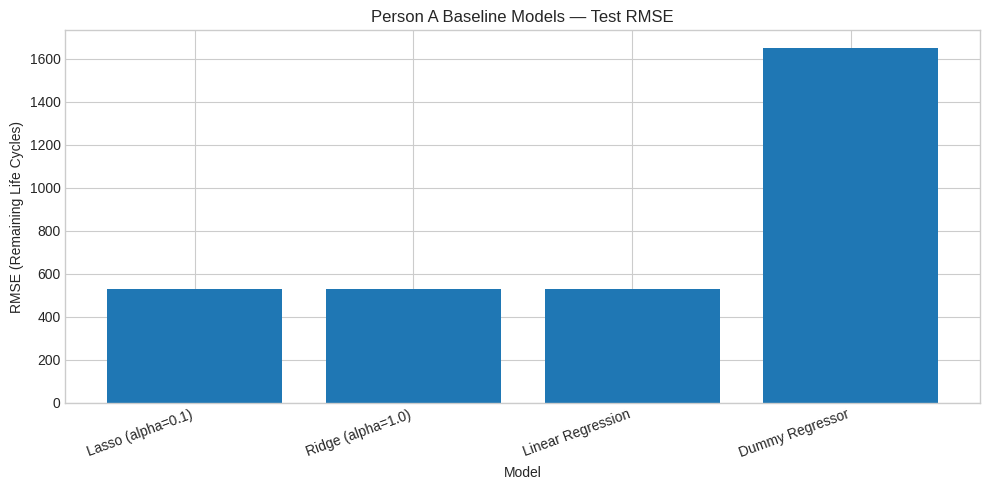

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["Test RMSE"]
)

plt.title("Person A Baseline Models — Test RMSE")
plt.ylabel("RMSE (Remaining Life Cycles)")
plt.xlabel("Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Analysis & Viva Preparation Notes

The bar chart visually confirms the large gap between the Dummy Regressor and the three actual regression models.

**What to say in the viva:** The Dummy benchmark has a much larger RMSE, while Linear Regression, Ridge, and Lasso are clustered close together around the same error range. This shows that the predictor information is useful, while regularization changes performance only slightly at the baseline settings.


## 14. Ridge and Lasso Alpha Tuning — Holdout Validation

For Stage 7, Person A tunes only the regularization strength `alpha` for Ridge and Lasso.

A **validation subset is created from the training partition**. The outer test set is not used to choose alpha.

This notebook intentionally uses a single holdout validation strategy rather than 5-fold cross-validation.


In [14]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Sub-training samples: {X_subtrain.shape[0]:,}")
print(f"Validation samples:   {X_val.shape[0]:,}")
print(f"Outer test samples:   {X_test.shape[0]:,}")


Sub-training samples: 12,224
Validation samples:   3,057
Outer test samples:   3,821


### Analysis & Viva Preparation Notes

**Observed validation split:**
- Sub-training samples: **12,224**
- Validation samples: **3,057**
- Outer test samples: **3,821**

**Why this split exists:** Ridge and Lasso need an `alpha` value. This internal validation set is used to compare candidate alpha values without using the outer test set for hyperparameter selection.

**Viva point:** The outer test set remains reserved for the final evaluation after the tuning decision is made.


### 14.1 Ridge Alpha Search


In [15]:
ridge_alphas = np.logspace(-4, 3, 15)

ridge_tuning_rows = []

for alpha in ridge_alphas:
    pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", Ridge(alpha=alpha))
    ])

    pipeline.fit(X_subtrain, y_subtrain)

    val_pred = pipeline.predict(X_val)

    ridge_tuning_rows.append({
        "alpha": alpha,
        "Validation RMSE": np.sqrt(
            mean_squared_error(y_val, val_pred)
        ),
        "Validation MAE": mean_absolute_error(
            y_val, val_pred
        ),
        "Validation R²": r2_score(
            y_val, val_pred
        )
    })

ridge_tuning = pd.DataFrame(ridge_tuning_rows)

best_ridge_row = ridge_tuning.loc[
    ridge_tuning["Validation RMSE"].idxmin()
]

best_ridge_alpha = float(best_ridge_row["alpha"])

print(f"Best Ridge alpha: {best_ridge_alpha:g}")
ridge_tuning.round(4)


Best Ridge alpha: 31.6228


,alpha,Validation RMSE,Validation MAE,Validation R²
0,0.0001,526.5627,419.1666,0.9027
1,0.0003,526.5627,419.1666,0.9027
2,0.0010,526.5627,419.1666,0.9027
3,0.0032,526.5626,419.1665,0.9027
4,0.0100,526.5622,419.1662,0.9027
5,0.0316,526.5610,419.1652,0.9027
6,0.1000,526.5573,419.1621,0.9027
7,0.3162,526.5458,419.1525,0.9027
8,1.0000,526.5129,419.1272,0.9027
9,3.1623,526.4331,419.0715,0.9027


### Analysis & Viva Preparation Notes

**Observed Ridge tuning result:**
- Best validation alpha: approximately **31.6228**
- Best validation RMSE: approximately **526.21 cycles**
- Validation MAE: approximately **418.94 cycles**
- Validation R²: approximately **0.9028**

**Interpretation:** Moderate Ridge regularization gives the lowest validation RMSE among the tested alpha values. Very large alpha values begin to increase validation error, indicating that excessive regularization can remove too much model flexibility.


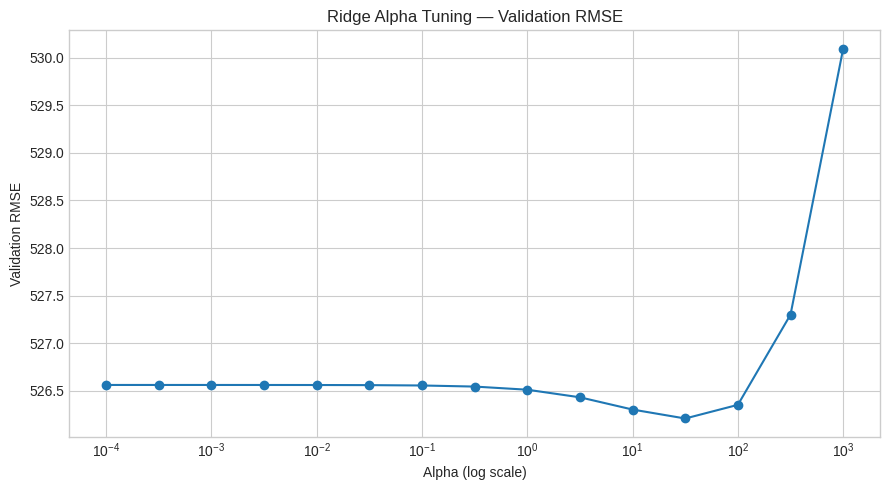

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    ridge_tuning["alpha"],
    ridge_tuning["Validation RMSE"],
    marker="o"
)

plt.xscale("log")
plt.title("Ridge Alpha Tuning — Validation RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()


### Analysis & Viva Preparation Notes

The Ridge tuning plot shows how validation RMSE changes as `alpha` increases on a logarithmic scale.

**What to explain:** Small alpha values behave similarly to ordinary linear regression. Performance improves slightly up to a moderate regularization level, then worsens when alpha becomes too large. That worsening is consistent with underfitting caused by overly strong regularization.


### 14.2 Lasso Alpha Search


In [17]:
lasso_alphas = np.logspace(-4, 2, 13)

lasso_tuning_rows = []

for alpha in lasso_alphas:
    pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", Lasso(
            alpha=alpha,
            max_iter=50000,
            random_state=RANDOM_STATE
        ))
    ])

    pipeline.fit(X_subtrain, y_subtrain)

    val_pred = pipeline.predict(X_val)

    lasso_tuning_rows.append({
        "alpha": alpha,
        "Validation RMSE": np.sqrt(
            mean_squared_error(y_val, val_pred)
        ),
        "Validation MAE": mean_absolute_error(
            y_val, val_pred
        ),
        "Validation R²": r2_score(
            y_val, val_pred
        )
    })

lasso_tuning = pd.DataFrame(lasso_tuning_rows)

best_lasso_row = lasso_tuning.loc[
    lasso_tuning["Validation RMSE"].idxmin()
]

best_lasso_alpha = float(best_lasso_row["alpha"])

print(f"Best Lasso alpha: {best_lasso_alpha:g}")
lasso_tuning.round(4)


Best Lasso alpha: 1


,alpha,Validation RMSE,Validation MAE,Validation R²
0,0.0001,526.5617,419.1659,0.9027
1,0.0003,526.5593,419.1644,0.9027
2,0.0010,526.5520,419.1594,0.9027
3,0.0032,526.5291,419.1436,0.9027
4,0.0100,526.4569,419.0943,0.9027
5,0.0316,526.3090,418.9909,0.9028
6,0.1000,525.9942,418.6987,0.9029
7,0.3162,525.8483,418.6361,0.9029
8,1.0000,525.6785,418.4723,0.9030
9,3.1623,526.9541,419.6006,0.9025


### Analysis & Viva Preparation Notes

**Observed Lasso tuning result:**
- Best validation alpha: **1.0**
- Best validation RMSE: approximately **525.68 cycles**
- Validation MAE: approximately **418.47 cycles**
- Validation R²: approximately **0.9030**

**Interpretation:** Among the tested Lasso values, `alpha=1.0` gives the lowest validation RMSE. Larger values such as 10, 31.62, and 100 progressively worsen the validation error, showing that excessive L1 regularization reduces predictive performance.


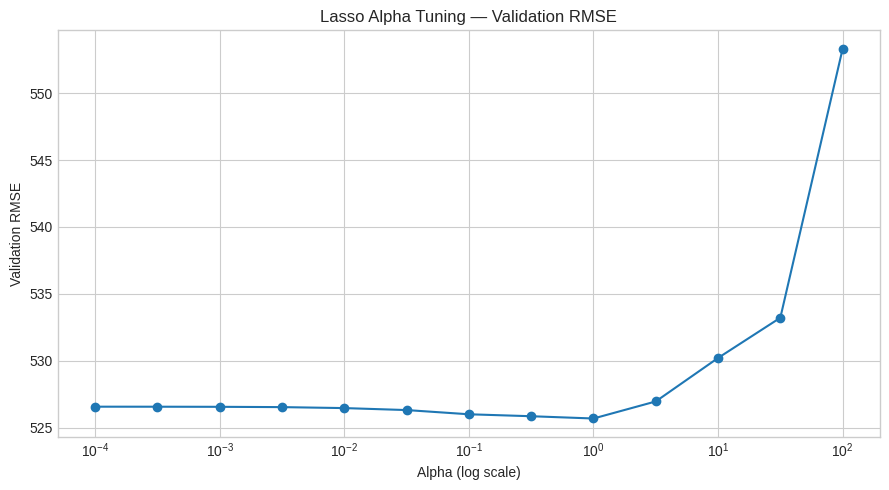

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    lasso_tuning["alpha"],
    lasso_tuning["Validation RMSE"],
    marker="o"
)

plt.xscale("log")
plt.title("Lasso Alpha Tuning — Validation RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()


### Analysis & Viva Preparation Notes

The Lasso tuning curve supports the selected `alpha=1.0`.

**Viva point:** The purpose of the plot is not only to show the best alpha but also to show the effect of regularization strength. When alpha becomes too large, validation RMSE rises because the model becomes too constrained.


## 15. Train the Tuned Ridge and Lasso Models

After selecting alpha from the internal validation split, each tuned model is retrained on the **full outer training set** and then evaluated on the untouched outer test set.


In [19]:
tuned_ridge_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", Ridge(alpha=best_ridge_alpha))
])

tuned_ridge_pipeline.fit(X_train, y_train)

tuned_ridge_result = evaluate_regression(
    f"Tuned Ridge (alpha={best_ridge_alpha:g})",
    tuned_ridge_pipeline,
    X_train, y_train,
    X_test, y_test
)


tuned_lasso_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", Lasso(
        alpha=best_lasso_alpha,
        max_iter=50000,
        random_state=RANDOM_STATE
    ))
])

tuned_lasso_pipeline.fit(X_train, y_train)

tuned_lasso_result = evaluate_regression(
    f"Tuned Lasso (alpha={best_lasso_alpha:g})",
    tuned_lasso_pipeline,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([
    tuned_ridge_result,
    tuned_lasso_result
]).round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Tuned Ridge (alpha=31.6228),0.9053,0.8963,519.5407,530.8349,413.7346,423.5636
1,Tuned Lasso (alpha=1),0.9049,0.8966,520.5547,530.1555,414.2568,423.0216


### Analysis & Viva Preparation Notes

**Observed tuned-model test results:**

**Tuned Ridge (`alpha≈31.6228`)**
- Test R²: approximately **0.8963**
- Test RMSE: approximately **530.83 cycles**
- Test MAE: approximately **423.56 cycles**

**Tuned Lasso (`alpha=1.0`)**
- Test R²: approximately **0.8966**
- Test RMSE: approximately **530.16 cycles**
- Test MAE: approximately **423.02 cycles**

**Interpretation:** Tuned Lasso provides the strongest test performance among Person A's evaluated linear-family models. The improvement is modest rather than dramatic, so it should be described accurately.


## 16. Final Person A Model Comparison


In [20]:
final_results = pd.DataFrame([
    dummy_result,
    linear_result,
    ridge_baseline_result,
    lasso_baseline_result,
    tuned_ridge_result,
    tuned_lasso_result
])

final_results = final_results.sort_values(
    by="Test RMSE"
).reset_index(drop=True)

final_results.round(4)


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Tuned Lasso (alpha=1),0.9049,0.8966,520.5547,530.1555,414.2568,423.0216
1,Lasso (alpha=0.1),0.9053,0.8964,519.5036,530.7154,413.6676,423.4065
2,Tuned Ridge (alpha=31.6228),0.9053,0.8963,519.5407,530.8349,413.7346,423.5636
3,Ridge (alpha=1.0),0.9054,0.8963,519.3181,530.9268,413.4301,423.4381
4,Linear Regression,0.9054,0.8963,519.3168,530.9497,413.4193,423.4515
5,Dummy Regressor,0.0000,-0.0015,1688.1572,1649.7870,1381.8507,1349.3024


### Analysis & Viva Preparation Notes

The final comparison table contains the Dummy benchmark, untuned linear-family baselines, and the tuned Ridge and Lasso models.

**Main observation:** All proper regression models are far better than the Dummy benchmark. Differences among Linear Regression, Ridge, and Lasso are relatively small, with tuned Lasso producing the lowest test RMSE in Person A's experiment.

**Viva point:** Use the table to justify conclusions with actual R², RMSE, and MAE rather than relying on a single metric.


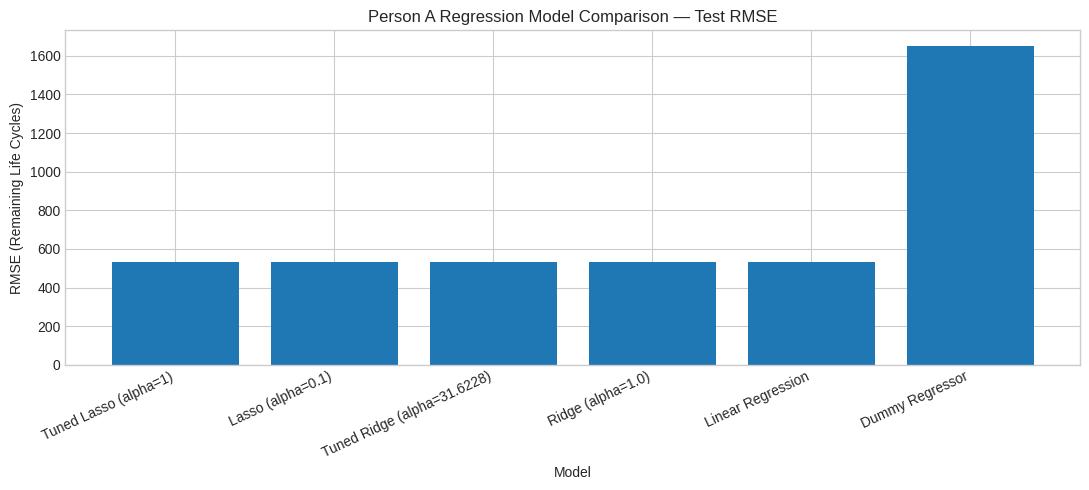

In [21]:
plt.figure(figsize=(11, 5))

plt.bar(
    final_results["Model"],
    final_results["Test RMSE"]
)

plt.title("Person A Regression Model Comparison — Test RMSE")
plt.ylabel("RMSE (Remaining Life Cycles)")
plt.xlabel("Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Analysis & Viva Preparation Notes

The final RMSE chart makes the systematic comparison easier to communicate.

**What to say:** The benchmark error is much larger than the errors from the trained regression models. Within the linear-family models, the bars are close together, which shows that their predictive performance is similar. Tuned Lasso has the lowest test RMSE, but only by a small margin.


## 17. Person A's Strongest Linear-Family Candidate

This step identifies the strongest model **only among the models evaluated by Person A**. It is not the final group-wide model selection.


In [22]:
person_a_candidates = final_results[
    final_results["Model"] != "Dummy Regressor"
].copy()

best_person_a_model = person_a_candidates.loc[
    person_a_candidates["Test RMSE"].idxmin()
]

print("Person A strongest linear-family candidate")
print("-------------------------------------------")
print(f"Model:     {best_person_a_model['Model']}")
print(f"Test R²:   {best_person_a_model['Test R²']:.4f}")
print(f"Test RMSE: {best_person_a_model['Test RMSE']:.4f}")
print(f"Test MAE:  {best_person_a_model['Test MAE']:.4f}")


Person A strongest linear-family candidate
-------------------------------------------
Model:     Tuned Lasso (alpha=1)
Test R²:   0.8966
Test RMSE: 530.1555
Test MAE:  423.0216


### Analysis & Viva Preparation Notes

**Observed Person A strongest linear-family candidate:** **Tuned Lasso (`alpha=1.0`)**

Approximate final test performance:
- Test R²: **0.8966**
- Test RMSE: **530.16 cycles**
- Test MAE: **423.02 cycles**

**Important viva wording:** This is only the strongest candidate among **Person A's assigned models**. It is not the final group-wide model because the tree/ensemble regressors developed by Person B still need to be compared at the group level.

**Justification:** Tuned Lasso has the lowest test RMSE, lowest test MAE, and highest test R² among the Person A candidates, although the margin over the other linear models is small.


## 18. Interpretation Guide for Viva 2

Use the actual values produced by this notebook when answering.

### Why use a Dummy Regressor?
It establishes a naive benchmark by predicting the training-set mean RUL. A useful predictive model should improve clearly over this benchmark.

### Why use Linear Regression?
It provides a simple and interpretable unregularized baseline and shows how well a linear relationship can explain remaining battery life.

### Why use Ridge Regression?
Ridge adds an L2 penalty. It is suitable when predictors are correlated because it discourages very large coefficients and can improve stability.

### Why use Lasso Regression?
Lasso adds an L1 penalty. In this notebook it is treated as a regularized regression model and compared with ordinary Linear Regression and Ridge.

### Why use R²?
R² shows the proportion of variation in the RUL target explained by the model.

### Why use RMSE?
RMSE is expressed in the same unit as the target — remaining life cycles — and penalizes large prediction errors more strongly.

### Why use MAE?
MAE gives the average absolute prediction error in remaining life cycles and is easy to interpret.

### How was alpha tuned?
A validation subset was created only from the outer training partition. Candidate alpha values were compared using validation RMSE. The alpha with the lowest validation RMSE was selected, after which the model was retrained using the full outer training set.

### Why was the outer test set not used to select alpha?
The test set should represent unseen data. Using it during hyperparameter selection would make the reported final test performance less independent.

### How do you discuss overfitting?
Compare training and testing metrics. A very strong training score combined with substantially worse testing performance can indicate overfitting. Similar train and test performance generally indicates more stable generalization.

### How do you justify Person A's strongest candidate?
Use the measured results. Prefer the model that provides the strongest overall test performance, especially lower RMSE and MAE together with higher R², while also considering the gap between training and testing performance.


## 19. Viva 2 — Person A Contribution Summary

A concise explanation:

> My responsibility was Task 1 linear and regularized regression for predicting `predicted_remaining_life_cycles`. I first established a Dummy Regressor benchmark, then trained ordinary Linear Regression, Ridge Regression, and Lasso Regression. I evaluated the models using R², RMSE, and MAE. For Ridge and Lasso, I tuned the regularization strength alpha using a validation subset taken only from the training partition, while keeping the outer test set separate. After choosing the best alpha values, I retrained the tuned models on the full training partition and compared their final test performance. I then identified the strongest candidate within my assigned linear-family models for later group-level comparison.
